In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
df1 = pd.read_csv("iris.csv")
print(df1.info())
df1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


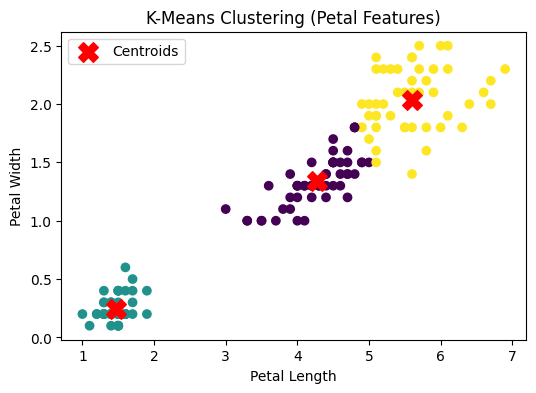

In [5]:
# Use only petal_length and petal_width
X = df1[['petal_length', 'petal_width']]

# Apply KMeans (initially assume k=3 since iris has 3 species)
kmeans = KMeans(n_clusters=3, random_state=42)
y_pred = kmeans.fit_predict(X)

# Add cluster labels to dataframe
df1['cluster'] = y_pred

# Plot clusters
plt.figure(figsize=(6,4))
plt.scatter(X['petal_length'], X['petal_width'], c=y_pred, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            color='red', marker='X', s=200, label='Centroids')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('K-Means Clustering (Petal Features)')
plt.legend()
plt.show()

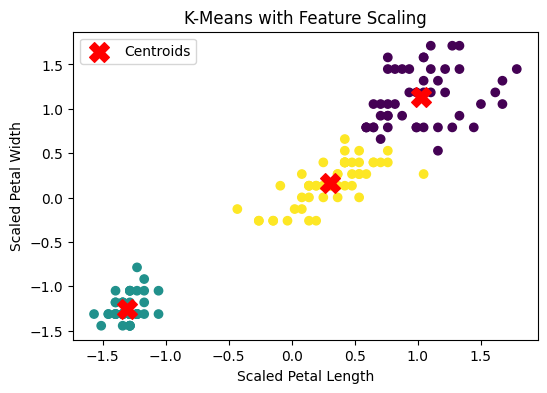

In [6]:
# Scaling features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans again
kmeans_scaled = KMeans(n_clusters=3, random_state=42)
y_pred_scaled = kmeans_scaled.fit_predict(X_scaled)

# Plot scaled clusters
plt.figure(figsize=(6,4))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_pred_scaled, cmap='viridis')
plt.scatter(kmeans_scaled.cluster_centers_[:,0], kmeans_scaled.cluster_centers_[:,1],
            color='red', marker='X', s=200, label='Centroids')
plt.xlabel('Scaled Petal Length')
plt.ylabel('Scaled Petal Width')
plt.title('K-Means with Feature Scaling')
plt.legend()
plt.show()

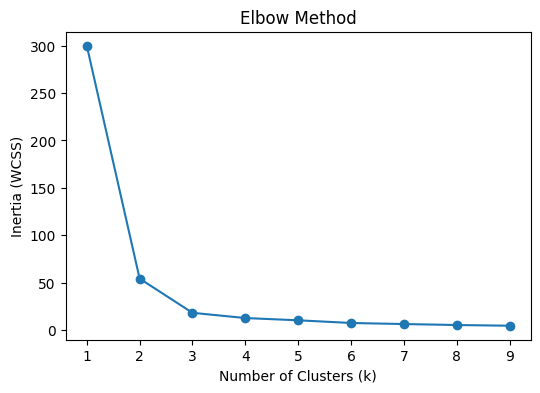

In [7]:
# Use scaled data for better results
inertia = []
k_range = range(1, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Plot elbow curve
plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method')
plt.show()